In [1]:
import xarray as xr 
import tams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
import seaborn as sns
import os
import numpy as np
import pickle as pkl
import logging

import mcs_analysis as mcsa

from joblib import Parallel, delayed
from scipy.stats import gaussian_kde
from pathlib import Path


import warnings
warnings.filterwarnings('ignore')

# Resolutions (from higher to lower)

- Original _Tb_ = 4 km

(a) 0.1x0.1 

(b) 0.25x0.25 

- Original _Tp_ (_pr_) = 0.1x0.1 _note_: Same as (a) from _Tb_

(a) 0.25x0.25 


# In this script, we are going to compare each resolution to see how much error we have accumulated.

With this, I will try to develop a function to compare error and store it, if possible, through a plot.

- Following line is just to test new function for open tp and tb files

In [11]:
ROOT = Path("../TFM/observations")
PR_PRE = "precipitation_IMERG_"
TB_PRE = "tb_merg_"

tp_file = f"{PR_PRE}2024_WA.nc"
tb_file = f"{TB_PRE}2024_WA.nc"

tp, tbI = mcsa.open_pr_tp(ROOT, tp_file, tb_file, isnan=False)

len(tbI.time.values)


5856

In [17]:
ds_2024 = xr.Dataset({'tb': tbI})
tbI_sel = tbI.sel(time=slice('2024-06-01', '2024-06-15'))
ds_sel = ds_2024.sel(time=slice('2024-06-01', '2024-06-15'))
len(tbI_sel.time.values)

720

- Generate 1999 for resolution 4 km (original)

In [4]:
cesI_1999, _ = tams.identify(tbI_sel, parallel=True);

cesI_1999_all = mcsa.Parallel_ds(cesI_1999, ds_sel, has_tp=False);

[Parallel(n_jobs=-2)]: Using backend LokyBackend with 63 concurrent workers.
[Parallel(n_jobs=-2)]: Done   2 tasks      | elapsed:   45.8s
[Parallel(n_jobs=-2)]: Done  19 tasks      | elapsed:   52.2s
[Parallel(n_jobs=-2)]: Done  36 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-2)]: Done  55 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-2)]: Done  74 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-2)]: Done  95 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-2)]: Done 116 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-2)]: Done 139 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-2)]: Done 162 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-2)]: Done 187 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-2)]: Done 212 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-2)]: Done 239 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-2)]: Done 266 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-2)]: Done 295 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-2)]: Done 324 tasks      | elapsed:  

In [5]:
cesI_2024_all = cesI_1999_all.copy()

In [6]:
mcsa.save_parquet(cesI_2024_all, "tams_2024_1month")

We need to create a new function that operates through statistical values to recreate error

In [7]:
data_path = Path("./TFM/parquet_sets")

file = str(data_path / "tams_2024_1month.parquet") #Resolution of 0.25x0.25 for 2024

times = tbI.time.values.tolist() # Times are the same for both resolution.
n_times = len(times)


In [8]:
# Open Parquet files (remember that these files come from tams.identify)
cesI_025 = mcsa.list_from_parquet(file, n_times)
#cesI_01 = mcsa.list_from_parquet(file_01, n_times)

In [9]:
cesT_025 = tams.track(cesI_025, times, u_projection=-10)
#cesT_01 = tams.track(cesI_01, times, u_projection=-10)

In [10]:
cesC_025 = tams.classify(cesT_025)
#cesC_01 = tams.classify(cesT_01)

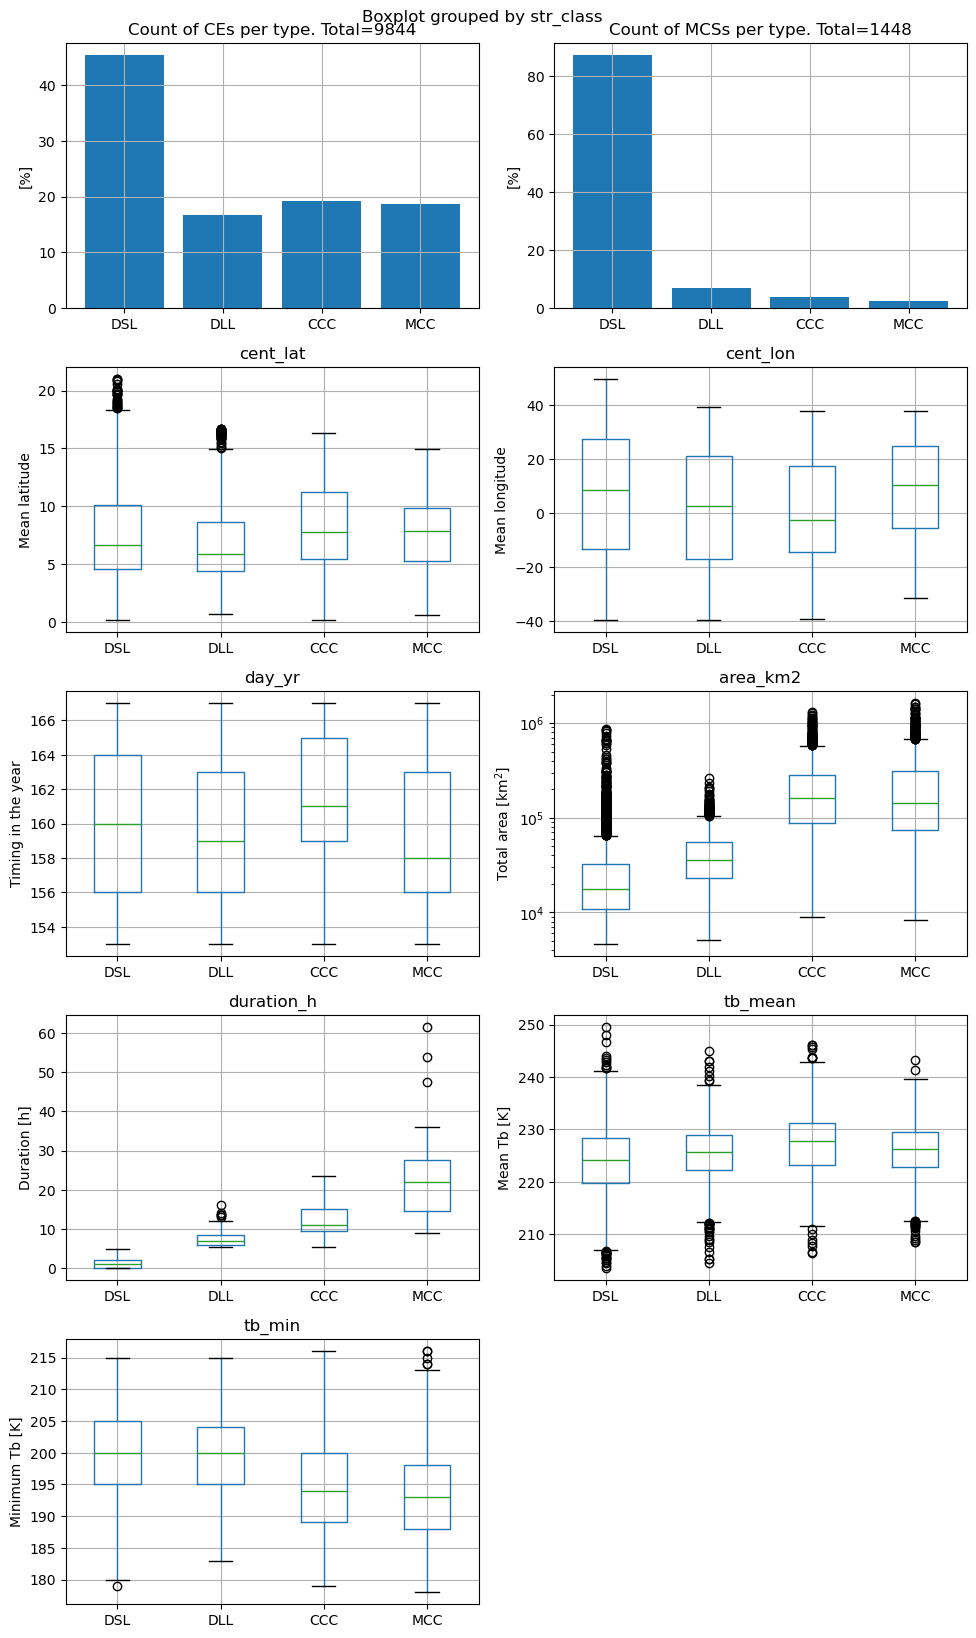

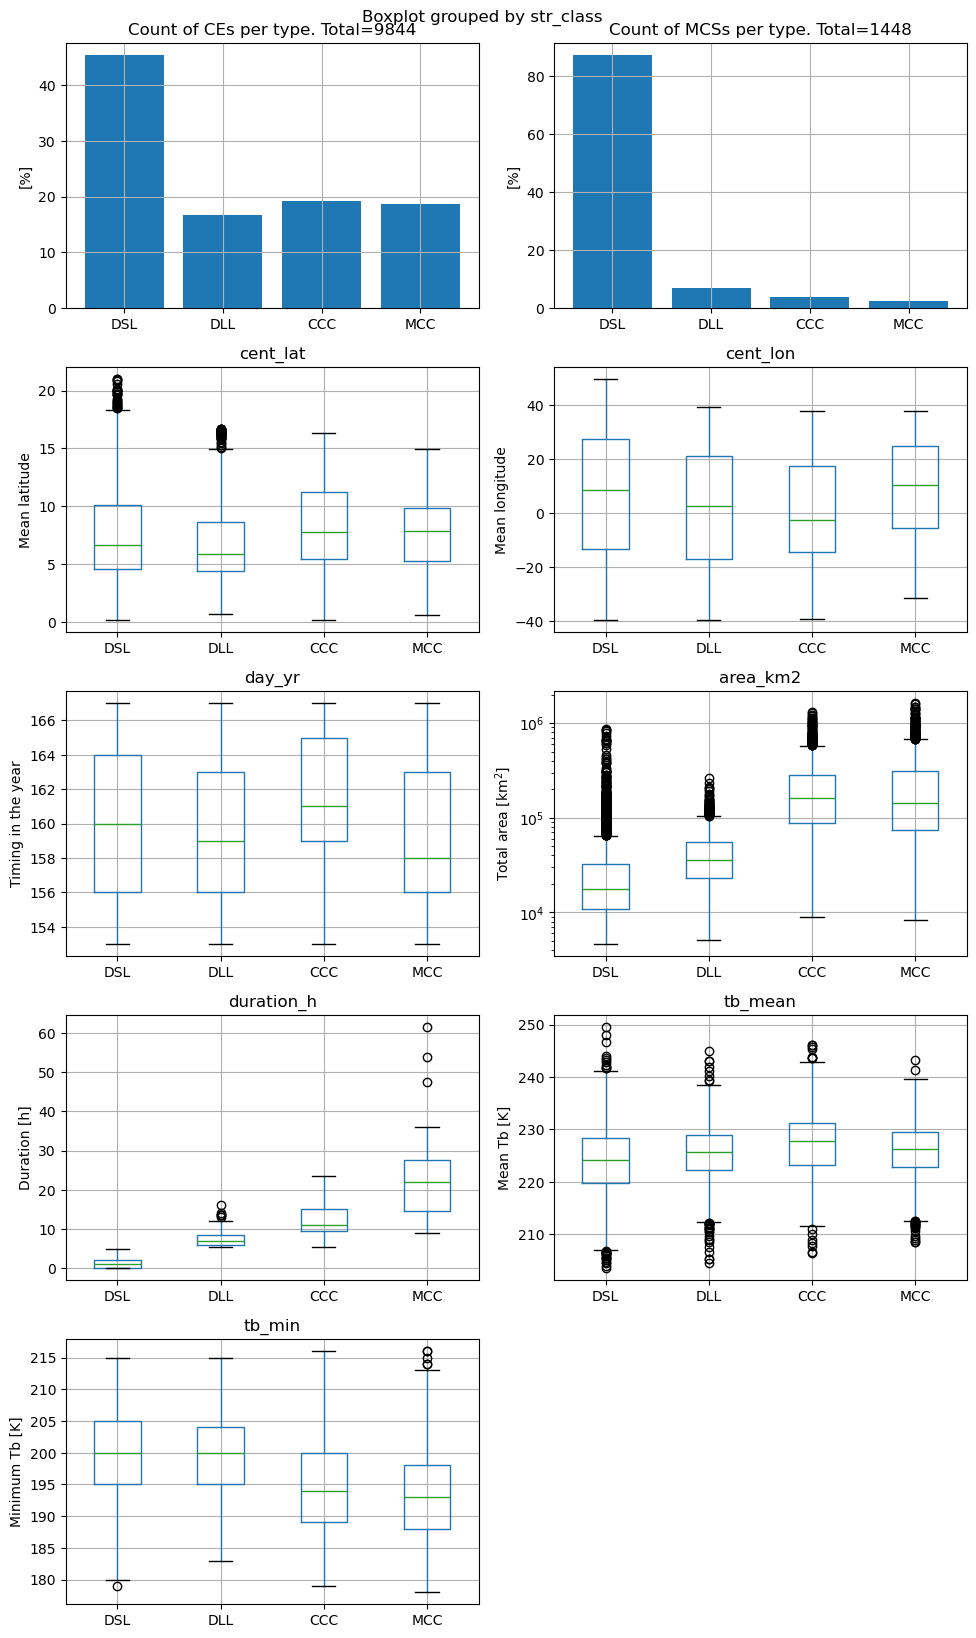

In [15]:
mcsa.dibujoMCS(cesC_025, has_tp=False)

- stats 2 semanas

In [16]:
stats = mcsa.mcs_class_stats(cesC_025, has_tp=False)

ce_pct  = stats["ces_total"] / stats["ces_total"].sum() * 100

# MCS percentages
mcs_pct = stats["mcs_total"] / stats["mcs_total"].sum() * 100

print(ce_pct.round(2))
print(mcs_pct.round(2)) 

mcs_class
DSL    45.36
DLL    16.77
CCC    19.23
MCC    18.64
Name: mcs_id, dtype: float64
mcs_class
DSL    87.09
DLL     6.77
CCC     3.87
MCC     2.28
Name: mcs_id, dtype: float64


- stats 1 mes 

In [20]:
stats = mcsa.mcs_class_stats(cesC_025, has_tp=False)

ce_pct  = stats["ces_total"] / stats["ces_total"].sum() * 100

# MCS percentages
mcs_pct = stats["mcs_total"] / stats["mcs_total"].sum() * 100

print(ce_pct.round(2))
print(mcs_pct.round(2)) 

mcs_class
DSL    46.05
DLL    16.96
CCC    17.54
MCC    19.46
Name: mcs_id, dtype: float64
mcs_class
DSL    87.42
DLL     6.74
CCC     3.52
MCC     2.32
Name: mcs_id, dtype: float64


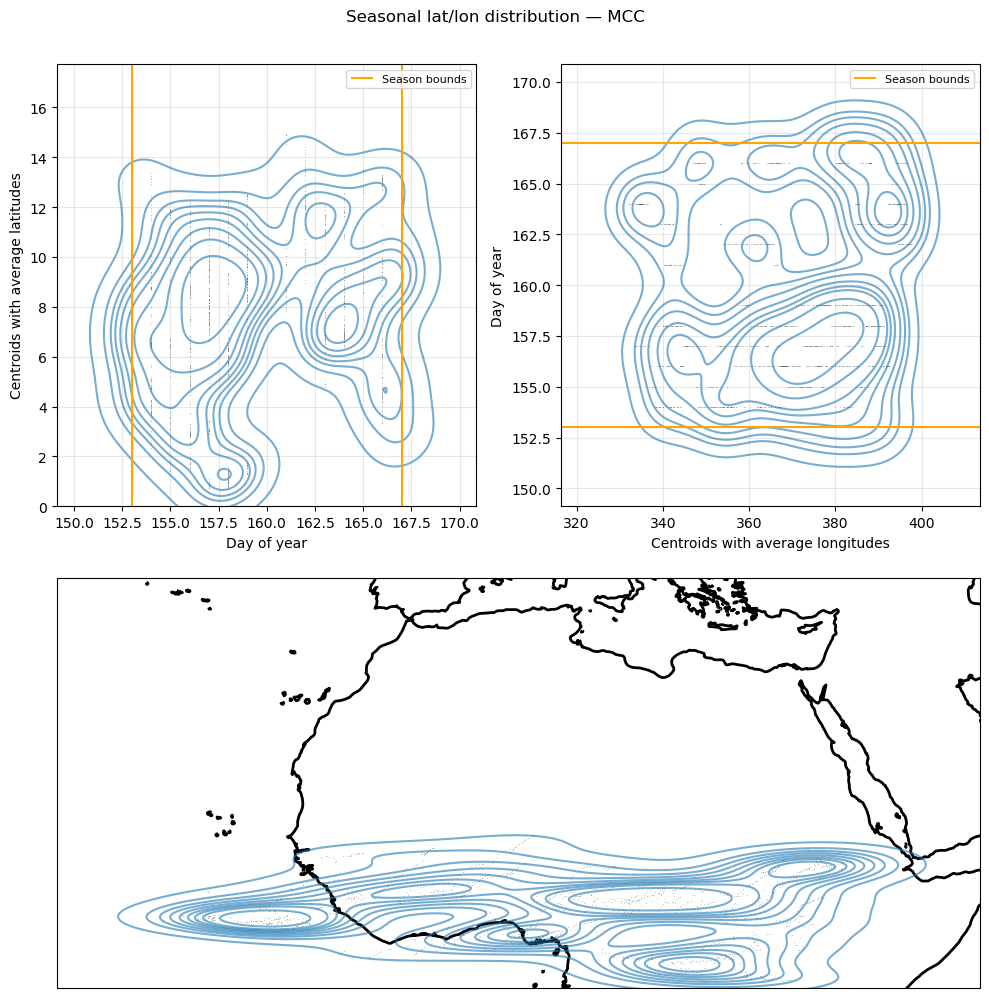

In [18]:
mcsa.seasonal_latlon(tbI_sel, stats, mcs_class='MCC')

- Save data as pkl to later use

In [11]:
cesC_025.to_pickle("cesC_2024_1month.pkl")
#cesC_01.to_pickle("cesC_2024_01.pkl")

In [19]:
cesC_025 = mcsa._load_classified("cesC_2024_1month", root= './' )
_MCS_ORDER = ["DSL", "DLL", "CCC", "MCC"]


In [ ]:
cesC_025 = mcsa._load_classified("cesC_2024_01")
print(cesC_025.groupby(["mcs_id", "itime"]).size().max())

9


## Now I'm gonna get stats from each resolution. 

This can be made with a new function that calculates stats